## Exam

## TASK 1

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder

data = {
    'age':    [25, None, 35, 40, None, 29],
    'salary': [50000, 60000, None, 80000, 55000, 62000],
    'city':   ['Tashkent', 'Samarkand', 'Tashkent', None, 'Bukhara', 'Samarkand'],
    'bought': [1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

## Filling missing values
df["age"]=df["age"].fillna(df["age"].median())
df["salary"]=df["salary"].fillna(df["salary"].median())
df["city"]=df['city'].fillna(df["city"].mode()[0])

# One-Hot Encoding
df=pd.get_dummies(df, columns=["city"])

# encoder=OneHotEncoder()
# df['city']=encoder.fit_transform(df[['city']])

# Scaling
scaler=StandardScaler()
df[["age","salary"]]=scaler.fit_transform(
    df[["age", "salary"]]
)

# Separate X and y
X=df.drop("bought", axis=1)
y=df['bought']

print(df)
print(X)
print(y)

In [ ]:
## Second way
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

data = {
    'age':    [25, None, 35, 40, None, 29],
    'salary': [50000, 60000, None, 80000, 55000, 62000],
    'city':   ['Tashkent', 'Samarkand', 'Tashkent', None, 'Bukhara', 'Samarkand'],
    'bought': [1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

# Separate X and y
X = df.drop("bought", axis=1)
y = df["bought"]

# Numerical columns
num_cols=X.select_dtypes(include=["int", "float"]).columns

# Categorical columns
cat_cols=X.select_dtypes(include=["str", "object"]).columns

# Numerical pipeline
num_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Columns Transformer
preprocessor=ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_final=preprocessor.fit_transform(X)
print(X_final)
print(y)


## Task 2

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt


# Load the dataset
iris=load_iris()

X=iris.data # type:ignore
y=iris.target # type:ignore

# Split dataset
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model=RandomForestClassifier(
    random_state=42,
    n_estimators=50,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    )
model.fit(X_train, y_train)

# Predictions
y_pred=model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Confusion Matrix
cm=confusion_matrix(y_test, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Classification Report
print("Classification Report:",classification_report(y_test, y_pred))

# Overfitting check
train_score=model.score(X_train, y_train)
test_score=model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

## Task 3

In [ ]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score

# Load dataset
iris=load_iris()

X=iris.data #type:ignore
y=iris.target # type:ignore

# Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models={
    "Logistic Regression":LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results=[]

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    
    accuracy=accuracy_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred, average="weighted")
    
    results.append([name, accuracy, f1])

# Table
results_df=pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "F1 Score"]
)
print(results_df)
 
# Cross Validation
print("\nCross Validation:\n")
for name, model in models.items():
    scores=cross_val_score(
        model, 
        X, y, cv=5
    )
    
    print(name)
    print("Mean CV Score:", scores.mean())
    print()


## Task 4

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

data = {
    'height_cm': [170, 165, 180, 155, 175],
    'weight_kg': [70, 60, 90, 50, 80],
    'age':       [25, 30, 22, 45, 35],
    'income':    [500, 300, 700, 200, 600],
    'expenses':  [400, 280, 500, 190, 450]
}

df = pd.DataFrame(data)

# BMI
df["BMI"]=df["weight_kg"]/(
    (df["height_cm"]/100)**2
)

# Savings
df["savings"]=df["income"]-df["expenses"]

# Age Group
def age_group(age):
    if age<30:
        return "young"
    elif age<=40:
        return "mid"
    else:
        return "senior"
    
    
df["age_group"]=df["age"].apply(age_group)

# High Saving
df["high_sving"]=(df["savings"]>df["savings"].median()).astype(int)

# X and y
X=df.drop("high_sving", axis=1)
y=df["high_sving"]

print(df)
print("Features:",X)
print("Target:",y)

# Encode Categorical 
X=pd.get_dummies(X)

# Creating model
model=RandomForestClassifier(random_state=42, max_depth=2)
model.fit(X, y)

importance_df=pd.DataFrame({
    'Feature': X.columns,
    "Importance":model.feature_importances_
})

print(importance_df.sort_values(
    by="Importance",
    ascending=False
))

   height_cm  weight_kg  age  income  expenses        BMI  savings age_group  \
0        170         70   25     500       400  24.221453      100     young   
1        165         60   30     300       280  22.038567       20       mid   
2        180         90   22     700       500  27.777778      200     young   
3        155         50   45     200       190  20.811655       10    senior   
4        175         80   35     600       450  26.122449      150       mid   

   high_sving  
0           0  
1           0  
2           1  
3           0  
4           1  
Features:    height_cm  weight_kg  age  income  expenses        BMI  savings age_group
0        170         70   25     500       400  24.221453      100     young
1        165         60   30     300       280  22.038567       20       mid
2        180         90   22     700       500  27.777778      200     young
3        155         50   45     200       190  20.811655       10    senior
4        175         80   35

## Task 5

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

# Basic info
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df["Survived"].value_counts())

# Fill missing values
df["Age"]=df["Age"].fillna(df['Age'].median())

df["Embarked"]=df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Drop columns
df=df.drop(
    columns=[
        "Cabin",
        "Name",
        "Ticket",
        "PassengerId"
    ]
)

# Encode
df["Sex"]=df["Sex"].map({"male":0, "female":1})
df=pd.get_dummies(df, columns=['Embarked'],drop_first=True, dtype=int)

# Scale
scaler=StandardScaler()
df[["Age", "Fare"]]=scaler.fit_transform(
    df[["Age", "Fare"]]
)

# Separate X and y
X=df.drop('Survived', axis=1)
y=df["Survived"]

# Split dataset
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)


(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64



 Logistic Regression
Accuracy: 0.8100558659217877
F1-score: 0.7638888888888888


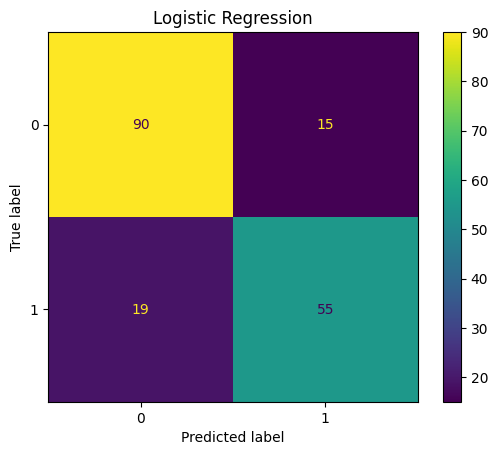


 Random Forest
Accuracy: 0.7988826815642458
F1-score: 0.7534246575342466


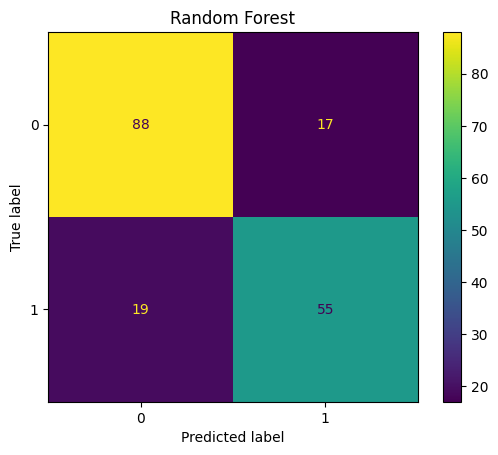

                 Model  Accuracy  F1-score
0  Logistic Regression  0.810056  0.763889
1        Random Forest  0.798883  0.753425


In [11]:
## MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results=[]

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, f1])
    
    print("\n", name)
    print("Accuracy:", accuracy)
    print("F1-score:", f1)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)

    plt.show()
    
    
# Comparison table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "F1-score"]
)

print(results_df)



In [13]:
# Test
new_data=pd.DataFrame([{
    'Pclass': 3,
    'Sex': 1,
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked_Q': 0,
    'Embarked_S': 1
}])

new_data[["Age", "Fare"]]=scaler.transform(
    new_data[["Age", "Fare"]]
)

# Best model
best_model = RandomForestClassifier(random_state=42, max_depth=3)
best_model.fit(X_train, y_train)

# Correct column order
new_data = new_data[X.columns]


print("Logistic Regression Prediction:", best_model.predict(new_data) )

Logistic Regression Prediction: [0]


## Task 5 Second way

In [16]:
#### Second way
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Load dataset

df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

# Drop unnecessary columns
df = df.drop(
    columns=[
        "Cabin",
        "Name",
        "Ticket",
        "PassengerId"
    ]
)

X=df.drop("Survived", axis=1)
y=df["Survived"]

# Numerical columns
num_cols=X.select_dtypes(include=["int", "float"]).columns

# Categorical columns
cat_cols=X.select_dtypes(include=["object", "str"]).columns

# Numerical pipeline
num_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(drop="first"))
])

# Column transformer
preprocessor=ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Split dataset
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [17]:
# Logistic Regression
log_reg=Pipeline([
    ("preprocessor", preprocessor),
    ('log_reg', LogisticRegression(max_iter=500))
])

log_reg.fit(X_train, y_train)

log_pred=log_reg.predict(X_test)

# Log Reg evaluation
print("Logistic Regression Accuracy Score:", accuracy_score(y_test, log_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, log_pred, average="weighted"))
print("Logistic Regression Confusion Matrix:", confusion_matrix(y_test, log_pred))

Logistic Regression Accuracy Score: 0.8100558659217877
Logistic Regression F1 Score: 0.8091929317716401
Logistic Regression Confusion Matrix: [[90 15]
 [19 55]]


In [18]:
# Random Forest
forest=Pipeline([
    ("preprocessor", preprocessor),
    ('forest', RandomForestClassifier(max_depth=3, random_state=42))
])

forest.fit(X_train, y_train)
forest_pred=forest.predict(X_test)

# Evaluate
print("Random Forest Accuracy Score:", accuracy_score(y_test, forest_pred))
print("Random Forest F1 Score:", f1_score(y_test, forest_pred, average="weighted"))
print("Random Forest Confusion Matrix:", confusion_matrix(y_test, forest_pred))

Random Forest Accuracy Score: 0.8044692737430168
Random Forest F1 Score: 0.7999607958443595
Random Forest Confusion Matrix: [[95 10]
 [25 49]]


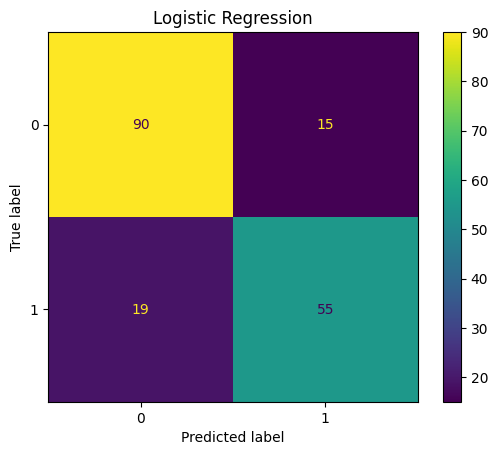

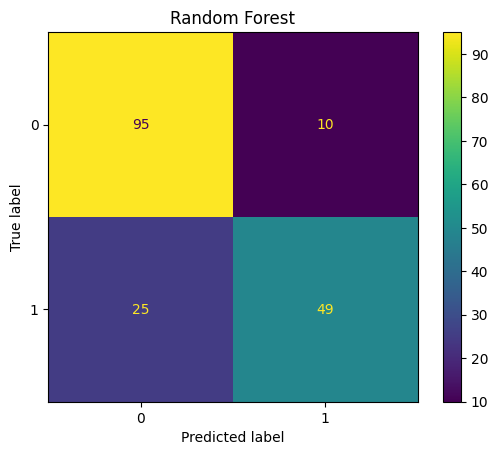

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression")

plt.show()

# Random Forest
cm = confusion_matrix(y_test, forest_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest")

plt.show()

In [20]:
# Final Test
# Best model pipeline

# Parameter grid
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

best_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
    ))
])

# GridSearchCV
grid_search=GridSearchCV(
    best_pipeline,
    param_grid,
    cv=5, 
    scoring="accuracy",
    n_jobs=-1
)



# Train best model
grid_search.fit(X_train, y_train)

# New passenger
new_data = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 'female',
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked': 'S'
}])

# Prediction
prediction = grid_search.predict(new_data)

print("Prediction:", prediction)

Prediction: [0]
